# New scaling

Testing the new scaling of z0 which makes alpha = 1.




In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
from main import FirnModel
import numpy as np
import matplotlib.pyplot as plt
import hvplot.xarray  


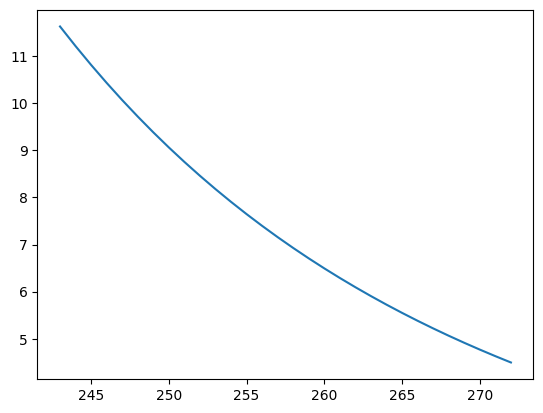

In [2]:
# z_0 = \frac{1}{\rho_i g} \left(\frac{k_g r_f^2}{k_c}\,\exp\left(\frac{E_c - E_g}{R T_s}\right)\right)^{\frac{1}{n}}

rho_i = 917  # ice density [kg / m**3]
g = 9.81  # gravitational acceleration [m / s**2]
E_c = 60e3  # compaction activation energy [J]
E_g = 42e3  # grain growth activation energy [J]
k_c = 9.2e-9  # flow parameter [kg?1 m3 s] from Arthern kc
r2_f = 0.01**2 
k_g = 1.3e-7 / r2_f  # grain growth rate constant [m**2 / s]
n=1
R = 8.314  # gas constant [J / (mol K)]

T_s_dim = np.arange(243, 273, 1)  # upper surface temperature [K]



z0 = 1 / (rho_i * g) * ((k_g * r2_f) / k_c * np.exp((E_c - E_g) / (R * T_s_dim)))**(1/n)
plt.plot(T_s_dim, z0)

In [3]:
FirnModel().setup(simDuration=8, Z=8, interp_on_reg_z=True).run().phi_r.plot()


*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  0.0395 seconds.
*** Post-processing.


NameError: name 'z0' is not defined

In [ ]:
R = FirnModel().setup(simDuration=8,Z=8, interp_on_reg_z=True).run()
R.phi_r.hvplot.line(x='z_r')

*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  0.0685 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids


BokehModel(combine_events=True, render_bundle={'docs_json': {'3a290225-5dea-44c7-89b0-b52dbd1df761': {'version…

Text(0, 0.5, 'depth [m]')

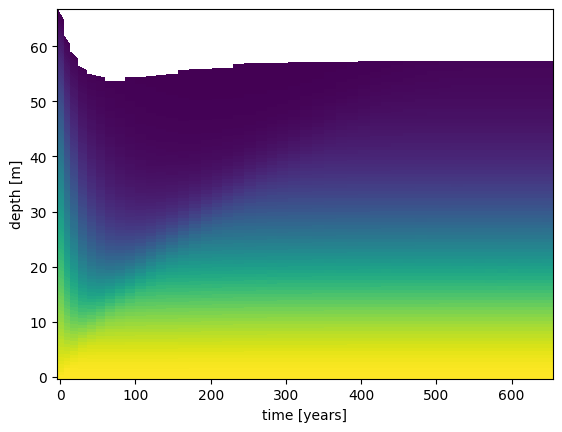

In [39]:
plt.pcolormesh(R.t*R.t.attrs['scale']/(60*60*24*365), R.z.attrs['scale']*R.z.values, R.phi_r.values)
plt.xlabel(f"time [years]")
plt.ylabel(f"depth [m]")

In [38]:
R.t.attrs['scale']/(60*60*24*365)

np.float64(81.59476207855668)